# Within-generation similarity analyses (perception / immediate / delay)

Loads `trials_final_sim.csv` for the three conditions of **one** generation / feedback type
and plots similarity analyses. Pick the generation with the `GEN` switch in the config cell
below (`aigen` | `nogen` | `plain`) — everything downstream keys off it, so switching feedback
type is a one-line change and figures save to a per-generation folder.

The comparison axis here is **task / memory load**: perception (sees the image) ->
immediate (describes from immediate memory) -> delayed memory. For comparing generations
*against each other* (aigen vs nogen vs plain), see `cross_gen_similarity_comparison.ipynb`.

**Conventions**
- We always plot **similarity**, never distance: `clip_similarity = 1 - clip_cosine_distance`,
  `vgg_similarity = 1 - vgg_fc7_distance`. `clip_vis_text_similarity` is already a similarity.
- One fixed, colorblind-safe color per task, reused in every figure.
- Individuals shown as faint lines behind bold **mean +/- 95% bootstrap CI** bands (N~23-25/condition).
- **Attempts are read from the data.** aigen/nogen run 3 attempts with feedback; `plain` runs
  only 1. When a generation has a single attempt (`SINGLE_ATTEMPT`), the over-attempts line
  figures become per-condition distributions and the refinement-only analyses
  (consecutive-attempt self-similarity, last-minus-first improvement delta) skip themselves.
- **Subjective ratings** exist only for aigen; `HAS_SUBJECTIVE` gates those cells the same way.
- **GPT baseline:** none in the current data. Code keeps an explicit (empty) `df_gpt`
  split keyed on `GPT_UID='gpt-5'` so it can be added later without restructuring.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Find project root (the dir containing config.py) regardless of where the notebook sits.
project_root = Path.cwd()
while not (project_root / "config.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config
print("project root:", project_root)

# --- GEN switch: pick the generation / feedback type to analyze ---
# "aigen" | "nogen" | "plain" — everything downstream keys off this one line.
GEN = "plain"
assert GEN in config.GROUPS_BY_GEN, f"unknown GEN={GEN!r}; choose from {list(config.GROUPS_BY_GEN)}"
print("GEN:", GEN, "->", config.GROUPS_BY_GEN[GEN])

project root: /mnt/hdd/anatkorol/Imagination_in_translation
GEN: plain -> ['plain_perc', 'plain_imm', 'plain_del']


In [2]:
# --- Load the three conditions of the chosen generation into one tidy frame ---
# (tagged condition/generation/task by config.load)
CONDITIONS = config.GROUPS_BY_GEN[GEN]         # e.g. ['aigen_perc', 'aigen_imm', 'aigen_del']
df = config.load(CONDITIONS, sim=True)         # reads each trials_final_sim.csv
assert not df.empty, f"no trials_final_sim.csv found for {GEN} — run the pipeline + add_similarity_scores first"

# Output location (shared per-generation folder beside perc/imm/del)
GRAPHS = config.ROOT / "analysis" / "outputs" / config.DATASET / GEN / "graphs"
GRAPHS.mkdir(parents=True, exist_ok=True)
print("saving figures to:", GRAPHS)
df["task"].value_counts()

saving figures to: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/plain/graphs


task
perception    121
immediate     114
delay          96
Name: count, dtype: int64

In [3]:
# --- Derived columns: distances -> similarities (we ALWAYS plot similarity) ---
df["clip_similarity"] = 1 - df["clip_cosine_distance"]
df["vgg_similarity"]  = 1 - df["vgg_fc7_distance"]
# clip_vis_text_similarity is already a similarity (no inversion)
df["prompt_word_len"] = df["prompt"].astype(str).str.split().str.len()
df["attempt"] = df["attempt"].astype(int)

# Keep the latest record per (task, uid, gt, attempt) in case of repeated slider moves.
df = df.sort_values("ts").groupby(["task", "uid", "gt", "attempt"], as_index=False, sort=False).tail(1)

# --- GPT baseline handling ---
# No gpt rows in the current aigen data. When a GPT baseline lands it will appear as
# uid == GPT_UID; keep it separate from human participants. Today df_gpt is empty.
GPT_UID = "gpt-5"
df_gpt = df[df["uid"] == GPT_UID].copy()
df_ppt = df[df["uid"] != GPT_UID].copy()
print(f"human rows: {len(df_ppt)} | gpt rows: {len(df_gpt)} (empty for now)")

# --- Subjective ratings exist only for aigen; nogen/plain collected none. ---
# Subjective-only figures/stats below key off this flag and skip themselves cleanly.
HAS_SUBJECTIVE = df_ppt["subjective_score"].notna().any()
print(f"subjective ratings present: {HAS_SUBJECTIVE}")

human rows: 331 | gpt rows: 0 (empty for now)
subjective ratings present: False


In [ ]:
# --- Style + fixed color maps (reused in every figure for alignment) ---
plt.style.use("seaborn-v0_8-whitegrid")

TASK_ORDER  = ["perception", "immediate", "delay"]
TASK_COLORS = {"perception": "#1b9e77", "immediate": "#d95f02", "delay": "#7570b3"}  # Dark2: green/orange/purple
TASK_LABELS = {"perception": "Perception", "immediate": "Immediate memory", "delay": "Delayed memory"}

# --- Attempts are read from the data, not hard-coded. ---
# aigen/nogen give feedback and run 3 attempts; `plain` has no feedback loop and only 1.
# SINGLE_ATTEMPT switches the over-attempts figures to single-point distributions and
# makes the refinement-specific analyses (self-similarity, attempt3-attempt1 delta) skip
# themselves, so the same notebook runs end-to-end for every generation.
ATTEMPTS       = sorted(df_ppt["attempt"].unique().tolist())
FINAL_ATTEMPT  = max(ATTEMPTS)
SINGLE_ATTEMPT = len(ATTEMPTS) == 1
print(f"attempts present: {ATTEMPTS} (single-attempt generation: {SINGLE_ATTEMPT})")

# Similarity metrics: column -> axis label. y-limits left to autoscale so new data isn't clipped.
# subjective_score is included only when the generation actually collected it (aigen);
# nogen/plain have no subjective rating, so it is dropped from every metric loop below.
SIM_METRICS = {}
if HAS_SUBJECTIVE:
    SIM_METRICS["subjective_score"] = "Subjective similarity (0-100)"
SIM_METRICS.update({
    "clip_similarity":          "CLIP similarity",
    "vgg_similarity":           "VGG fc7 similarity",
    "clip_vis_text_similarity": "CLIP vision-text alignment",
})
print("similarity metrics in use:", list(SIM_METRICS))
METRIC_COLORS = {"CLIP": "#377eb8", "VGG": "#e41a1c", "Subjective": "#4daf4a"}
GPT_COLOR = "black"  # reserved styling for the future GPT baseline line

In [ ]:
# --- Reusable plotters (guarantee identical colors everywhere) ---
def _ppt_attempt_means(data, metric):
    """Mean of `metric` per (task, uid, attempt) -> the per-participant points we aggregate over."""
    return data.dropna(subset=[metric]).groupby(["task", "uid", "attempt"], as_index=False)[metric].mean()

def _plot_metric_single_attempt(g, metric, ylabel, gpt_data, ax, show_individuals):
    """SINGLE_ATTEMPT layout: no x-axis to walk along, so show the distribution per condition.

    Violin + per-participant points + bold mean with a 95% bootstrap CI, one column per task.
    """
    pm = g[g["attempt"] == FINAL_ATTEMPT]
    sns.violinplot(data=pm, x="task", y=metric, order=TASK_ORDER, ax=ax,
                   hue="task", palette=TASK_COLORS, legend=False, inner=None, cut=0, alpha=0.35)
    if show_individuals:
        sns.stripplot(data=pm, x="task", y=metric, order=TASK_ORDER, ax=ax,
                      color="0.2", size=4, alpha=0.55, jitter=0.15, zorder=2)
    sns.pointplot(data=pm, x="task", y=metric, order=TASK_ORDER, ax=ax,
                  hue="task", palette=TASK_COLORS, legend=False,
                  errorbar=("ci", 95), linestyle="none", marker="o", markersize=9,
                  capsize=0.12, err_kws={"linewidth": 2.2}, zorder=3)
    if gpt_data is not None and not gpt_data.empty:
        ax.axhline(gpt_data[metric].mean(), color=GPT_COLOR, lw=2.5, ls="--", label="GPT", zorder=4)
        ax.legend(frameon=True)
    ax.set_xlabel(""); ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(TASK_ORDER)))
    ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER], rotation=15)

def plot_metric_over_attempts(metric, ylabel, data=None, show_individuals=True, fname=None, title=None, ylim=None):
    """One line per condition: faint per-participant lines + bold mean +/- 95% bootstrap CI.

    With a single-attempt generation (`plain`) there is nothing to plot *over*, so this
    falls back to a per-condition distribution figure with the same colors and file name.
    """
    data = df_ppt if data is None else data
    if metric not in data.columns:
        print(f"column {metric!r} not in the data - skipping '{title or ylabel}'")
        return
    g = _ppt_attempt_means(data, metric)
    if g.empty:
        print(f"no non-null values for {metric!r} - skipping '{title or ylabel}'")
        return
    gpt_data = _ppt_attempt_means(df_gpt, metric) if (data is df_ppt and not df_gpt.empty) else None
    fig, ax = plt.subplots(figsize=(7.5, 5.5))

    if SINGLE_ATTEMPT:
        _plot_metric_single_attempt(g, metric, ylabel, gpt_data, ax, show_individuals)
        # Callers pass "... over attempts" titles; there is only one attempt here.
        ax.set_title((title or ylabel).replace(" over attempts", "") + " by condition")
    else:
        for task in TASK_ORDER:
            sub = g[g["task"] == task]
            if sub.empty:
                continue
            color = TASK_COLORS[task]
            if show_individuals:
                wide = sub.pivot(index="uid", columns="attempt", values=metric)
                for _, row in wide.iterrows():
                    ax.plot(ATTEMPTS, [row.get(a, np.nan) for a in ATTEMPTS],
                            color=color, alpha=0.12, lw=0.8, zorder=1)
            sns.lineplot(data=sub, x="attempt", y=metric, ax=ax, color=color, lw=2.6,
                         marker="o", markersize=7, errorbar=("ci", 95),
                         label=TASK_LABELS[task], zorder=3)
        # Future GPT baseline: when df_gpt is non-empty, draw it as a black reference line.
        if gpt_data is not None:
            gg = gpt_data.groupby("attempt")[metric].mean()
            ax.plot(ATTEMPTS, [gg.get(a, np.nan) for a in ATTEMPTS],
                    color=GPT_COLOR, lw=3, ls="--", marker="s", label="GPT", zorder=4)
        ax.set_xticks(ATTEMPTS); ax.set_xticklabels([f"Attempt {a}" for a in ATTEMPTS])
        ax.set_xlabel(""); ax.set_ylabel(ylabel)
        ax.set_title(title or f"{ylabel} over attempts")
        ax.legend(title="Condition", frameon=True)

    if ylim is not None:
        ax.set_ylim(ylim)
    fig.tight_layout()
    if fname:
        fig.savefig(GRAPHS / fname, dpi=300, bbox_inches="tight")
    plt.show()

def per_ppt_corr(data, xcol, ycol, method="pearson"):
    """Within-participant correlation of xcol vs ycol, one row per (task, uid)."""
    fn = pearsonr if method == "pearson" else spearmanr
    rows = []
    for (task, uid), sub in data.groupby(["task", "uid"]):
        s = sub[[xcol, ycol]].dropna()
        if len(s) < 3 or s[xcol].nunique() < 2 or s[ycol].nunique() < 2:
            continue
        r, _ = fn(s[xcol], s[ycol])
        rows.append({"task": task, "uid": uid, "r": r})
    return pd.DataFrame(rows)

## Data overview

In [5]:
overview = (df_ppt.groupby("task")
            .agg(n_participants=("uid", "nunique"),
                 n_trials=("uid", "size"),
                 mean_subjective=("subjective_score", "mean"))
            .reindex(TASK_ORDER))
display(overview)
display(df_ppt.pivot_table(index="task", columns="attempt", values="uid",
                           aggfunc="count").reindex(TASK_ORDER))

NameError: name 'TASK_ORDER' is not defined

## A1. Metric sanity & subjective-objective agreement
How well do the objective metrics agree with each other, and with participants' subjective ratings?

In [6]:
tmp = df_ppt[["clip_similarity", "vgg_similarity"]].dropna()
r, p = pearsonr(tmp["clip_similarity"], tmp["vgg_similarity"])
print(f"CLIP vs VGG similarity (all trials): r={r:.3f}, p={p:.3g}")
for task in TASK_ORDER:
    s = df_ppt[df_ppt["task"] == task][["clip_similarity", "vgg_similarity"]].dropna()
    r, p = pearsonr(s["clip_similarity"], s["vgg_similarity"])
    print(f"  {TASK_LABELS[task]:18s}: r={r:.3f}, p={p:.3g}")

# Subjective vs objective only when subjective ratings were collected (aigen).
if HAS_SUBJECTIVE:
    for obj in ["clip_similarity", "vgg_similarity"]:
        s = df_ppt[["subjective_score", obj]].dropna()
        r, p = pearsonr(s["subjective_score"], s[obj])
        print(f"subjective vs {obj}: r={r:.3f}, p={p:.3g}")
else:
    print("no subjective ratings for this generation - skipping subjective-objective correlations")

CLIP vs VGG similarity (all trials): r=0.482, p=1.15e-20


NameError: name 'TASK_ORDER' is not defined

In [31]:
if not HAS_SUBJECTIVE:
    print("no subjective ratings for this generation - skipping subjective-objective agreement figure")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
    for ax, obj, name in zip(axes, ["clip_similarity", "vgg_similarity"], ["CLIP", "VGG"]):
        c = per_ppt_corr(df_ppt, "subjective_score", obj, method="pearson")
        sns.barplot(data=c, x="task", y="r", order=TASK_ORDER, ax=ax,
                    hue="task", palette=TASK_COLORS, legend=False, errorbar="se")
        sns.stripplot(data=c, x="task", y="r", order=TASK_ORDER, ax=ax,
                      color="0.25", size=4, alpha=0.6, jitter=0.15)
        means = c.groupby("task")["r"].mean().reindex(TASK_ORDER)
        for i, m in enumerate(means):
            ax.text(i, m, f"{m:.2f}", ha="center", va="bottom", fontsize=9)
        ax.axhline(0, color="black", ls="--", lw=1)
        ax.set_title(f"Subjective vs {name}")
        ax.set_xlabel(""); ax.set_ylabel("within-participant Pearson r")
        ax.set_xticks(range(len(TASK_ORDER)))
        ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER], rotation=15)
    fig.suptitle("Subjective-objective agreement by condition (per participant)")
    fig.tight_layout()
    fig.savefig(GRAPHS / "subjective_objective_corr_by_condition.png", dpi=300, bbox_inches="tight")
    plt.show()

no subjective ratings for this generation - skipping subjective-objective agreement figure


## A2. Prompt length & token count over attempts
Do people write longer descriptions when relying on memory, or as they refine across attempts?

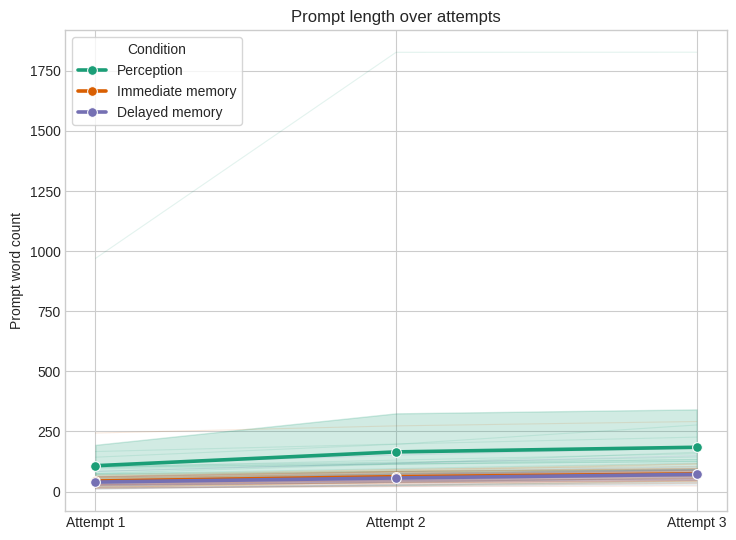

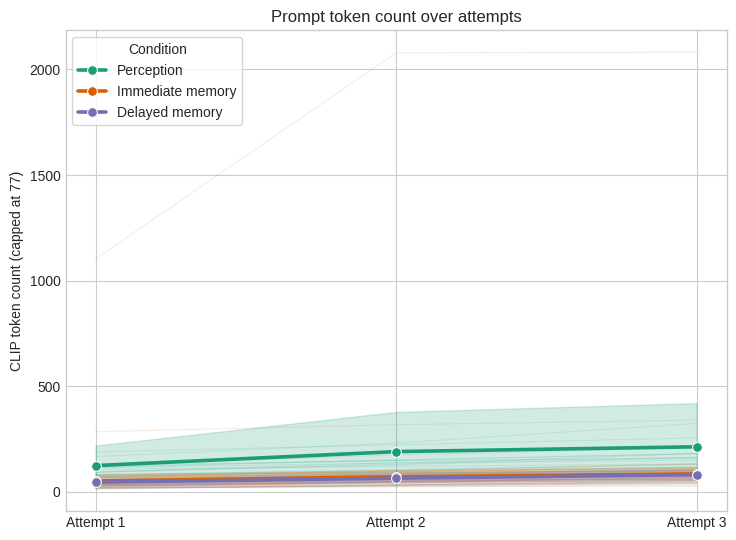

In [32]:
plot_metric_over_attempts("prompt_word_len", "Prompt word count",
                          fname="prompt_length_over_attempts_by_condition.png",
                          title="Prompt length over attempts")
plot_metric_over_attempts("token_num", "CLIP token count",
                          fname="token_count_over_attempts_by_condition.png",
                          title="Prompt token count over attempts",
                          ylim=(0, 100))  # adjust the y-axis range as you like

## A3-B7. Similarity over attempts, by condition - headline figures
For each metric: one line per condition (mean +/- 95% CI), faint participant lines behind.
Shows whether perception > immediate > delay and whether the attempt-1->3 gain differs by memory load.

For **single-attempt generations (`plain`)** the same calls render a per-condition
**distribution** instead (violin + participant points + mean with 95% CI), same colors, same file names.

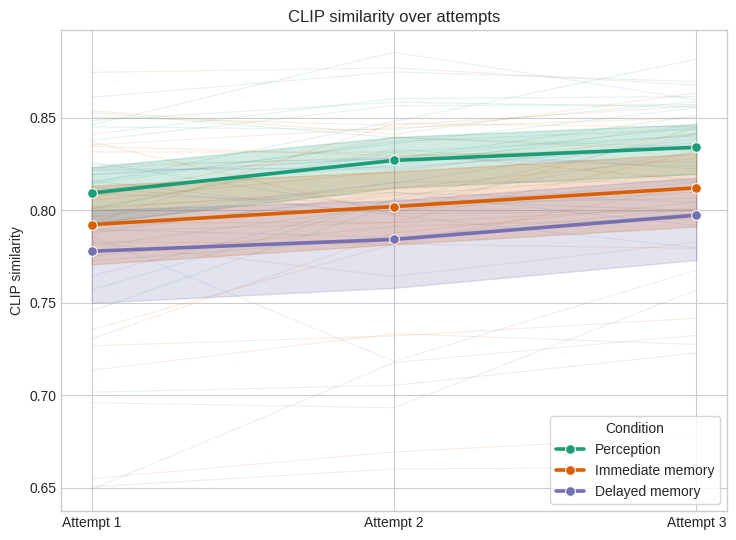

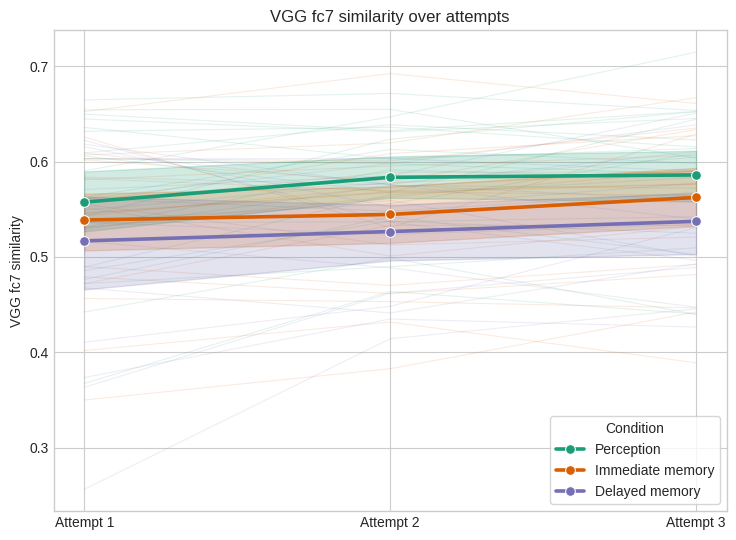

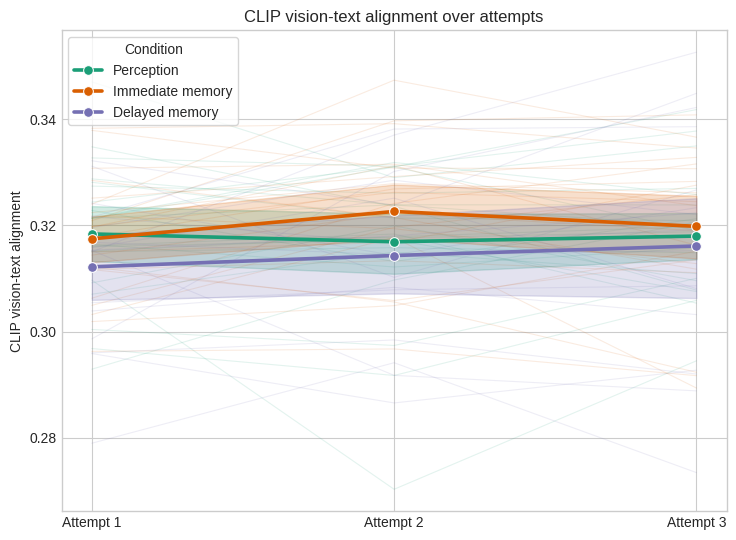

In [33]:
for metric, ylabel in SIM_METRICS.items():
    plot_metric_over_attempts(metric, ylabel,
                              fname=f"{metric}_over_attempts_by_condition.png",
                              title=f"{ylabel} over attempts")

## Consecutive-attempt self-similarity
CLIP cosine similarity between a participant's gen image at attempt *n* and the previous
attempt (*n-1*), within the same target. Measures **refinement / convergence** — how much
the output changes between tries — rather than distance to the GT. Attempt 1 has no
predecessor, so the line starts at attempt 2.

*(Requires re-running `add_similarity_scores.py` so `clip_self_prev_similarity` is in the CSVs.)*

**Skipped for single-attempt generations (`plain`)** — there is no previous attempt.

In [ ]:
if SINGLE_ATTEMPT:
    print("single-attempt generation - no previous attempt to compare against, skipping")
else:
    plot_metric_over_attempts(
        "clip_self_prev_similarity",
        "CLIP self-similarity (attempt n vs n-1)",
        fname="clip_self_prev_similarity_over_attempts_by_condition.png",
        title="Consecutive-attempt self-similarity over attempts")

## B8. Final-attempt similarity distribution by condition
Where each condition lands after all feedback - does memory load lower the achievable similarity?
The "final attempt" is `FINAL_ATTEMPT`: attempt 3 for aigen/nogen, attempt 1 for `plain`
(where it is simply *the* attempt, so this figure is the headline distribution).

In [ ]:
# Final attempt = the last attempt this generation actually ran (3 for aigen/nogen, 1 for plain).
final = df_ppt[df_ppt["attempt"] == FINAL_ATTEMPT]
fig, axes = plt.subplots(1, len(SIM_METRICS), figsize=(5 * len(SIM_METRICS), 5))
axes = np.atleast_1d(axes)
for ax, (metric, ylabel) in zip(axes, SIM_METRICS.items()):
    pm = final.groupby(["task", "uid"], as_index=False)[metric].mean()
    sns.violinplot(data=pm, x="task", y=metric, order=TASK_ORDER, ax=ax,
                   hue="task", palette=TASK_COLORS, legend=False, inner=None, cut=0)
    sns.stripplot(data=pm, x="task", y=metric, order=TASK_ORDER, ax=ax,
                  color="0.2", size=4, alpha=0.7, jitter=0.15)
    ax.set_xlabel(""); ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(TASK_ORDER)))
    ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER], rotation=15)
label = "Single-attempt" if SINGLE_ATTEMPT else f"Attempt-{FINAL_ATTEMPT}"
fig.suptitle(f"{label} similarity by condition (participant means)")
fig.tight_layout()
fig.savefig(GRAPHS / f"attempt{FINAL_ATTEMPT}_similarity_distribution_by_condition.png",
            dpi=300, bbox_inches="tight")
plt.show()

## B9. Improvement delta(last attempt - first attempt) by condition
How much does the feedback loop help, and does the benefit depend on memory load?

**Skipped for single-attempt generations (`plain`)** — there is no feedback loop to improve across.

In [ ]:
if SINGLE_ATTEMPT:
    print("single-attempt generation - no feedback loop to improve across, skipping")
else:
    FIRST, LAST = min(ATTEMPTS), FINAL_ATTEMPT
    rows = []
    for metric in SIM_METRICS:
        pm = df_ppt.groupby(["task", "uid", "attempt"], as_index=False)[metric].mean()
        wide = pm.pivot_table(index=["task", "uid"], columns="attempt", values=metric)
        wide = wide.dropna(subset=[FIRST, LAST])
        delta = (wide[LAST] - wide[FIRST]).rename("delta").reset_index()
        delta["metric"] = metric
        rows.append(delta)
    deltas = pd.concat(rows, ignore_index=True)

    fig, axes = plt.subplots(1, len(SIM_METRICS), figsize=(5 * len(SIM_METRICS), 5))
    axes = np.atleast_1d(axes)
    for ax, metric in zip(axes, SIM_METRICS):
        d = deltas[deltas["metric"] == metric]
        sns.barplot(data=d, x="task", y="delta", order=TASK_ORDER, ax=ax,
                    hue="task", palette=TASK_COLORS, legend=False, errorbar="se")
        sns.stripplot(data=d, x="task", y="delta", order=TASK_ORDER, ax=ax,
                      color="0.2", size=4, alpha=0.6, jitter=0.15)
        ax.axhline(0, color="black", ls="--", lw=1)
        ax.set_title(SIM_METRICS[metric]); ax.set_xlabel("")
        ax.set_ylabel(f"delta (attempt{LAST} - attempt{FIRST})")
        ax.set_xticks(range(len(TASK_ORDER)))
        ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER], rotation=15)
    fig.suptitle("Improvement across attempts by condition")
    fig.tight_layout()
    fig.savefig(GRAPHS / "improvement_delta_by_condition.png", dpi=300, bbox_inches="tight")
    plt.show()

## A6. Per-ground-truth-image difficulty
Are some target images consistently harder to reconstruct? Mean VGG similarity per GT, by condition.

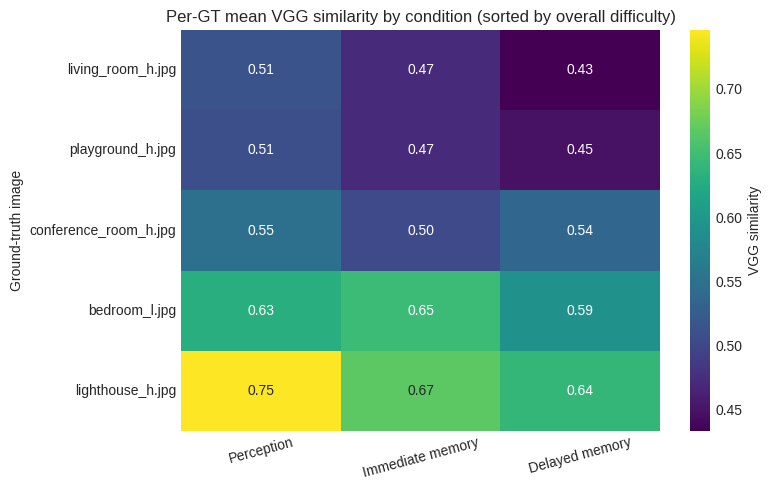

In [36]:
metric = "vgg_similarity"
gt_means = df_ppt.groupby(["gt", "task"], as_index=False)[metric].mean()
order = (gt_means.groupby("gt")[metric].mean().sort_values().index)
pivot = gt_means.pivot(index="gt", columns="task", values=metric).reindex(order)[TASK_ORDER]

fig, ax = plt.subplots(figsize=(8, max(5, 0.35 * len(order))))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis", ax=ax,
            cbar_kws={"label": "VGG similarity"})
ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER], rotation=15)
ax.set_ylabel("Ground-truth image"); ax.set_xlabel("")
ax.set_title("Per-GT mean VGG similarity by condition (sorted by overall difficulty)")
fig.tight_layout()
fig.savefig(GRAPHS / "per_gt_difficulty_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## B11. Response latencies by condition (secondary)
New logging columns: time to write the prompt, to generate, and to rate.

In [ ]:
lat_cols = [c for c in ["prompt_latency_secs", "generating_latency_secs", "rating_latency_secs"] if c in df_ppt.columns]
if lat_cols:
    fig, axes = plt.subplots(1, len(lat_cols), figsize=(5 * len(lat_cols), 5))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, lat_cols):
        g = _ppt_attempt_means(df_ppt, col)
        if SINGLE_ATTEMPT:
            # One attempt: compare conditions directly instead of walking across attempts.
            sns.barplot(data=g, x="task", y=col, order=TASK_ORDER, ax=ax,
                        hue="task", palette=TASK_COLORS, legend=False, errorbar=("ci", 95))
            sns.stripplot(data=g, x="task", y=col, order=TASK_ORDER, ax=ax,
                          color="0.2", size=4, alpha=0.6, jitter=0.15)
            ax.set_xticks(range(len(TASK_ORDER)))
            ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER], rotation=15)
        else:
            for task in TASK_ORDER:
                sub = g[g["task"] == task]
                sns.lineplot(data=sub, x="attempt", y=col, ax=ax, color=TASK_COLORS[task],
                             marker="o", lw=2.2, errorbar=("ci", 95), label=TASK_LABELS[task])
            ax.set_xticks(ATTEMPTS); ax.set_xticklabels([f"A{a}" for a in ATTEMPTS])
            ax.legend(title="Condition", fontsize=8)
        ax.set_title(col.replace("_", " ")); ax.set_xlabel(""); ax.set_ylabel("seconds")
    fig.suptitle("Latencies by condition" if SINGLE_ATTEMPT else "Latencies over attempts by condition")
    fig.tight_layout()
    fig.savefig(GRAPHS / "latencies_over_attempts_by_condition.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No latency columns present.")

---
### Adding the GPT baseline later
When a `gpt-5` row exists in the data it is automatically pulled into `df_gpt` (cell 4).
`plot_metric_over_attempts` already draws it as a black dashed reference line when `df_gpt`
is non-empty, so the over-attempts figures gain a GPT comparison with no other changes.